<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Hands_on_Activity_5_3_Bagging%2C_Boosting_and_Stacking_PART_I_(De_los_Reyes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Glass Classification using Bagging

## Introduction

In this activity, I will be using the [Glass Identification ](https://archive.ics.uci.edu/dataset/42/glass+identification) dataset from  UCI which contains 10 attributes including id.

**Attributes information**


* Id number: 1 to 214 (removed from CSV file)
* RI: refractive index
* Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
* Mg: Magnesium
* Al: Aluminum
* Si: Silicon
* K: Potassium
* Ca: Calcium
* Ba: Barium
* Fe: Iron
* Type of glass: (class attribute)
 1. building_windows_float_processed
 2. building_windows_non_float_processed
 3. vehicle_windows_float_processed
 4. vehicle_windows_non_float_processed (none in this database)
 5. containers
 6. tableware
 7. headlamps

In [ ]:
from __future__ import print_function
import os
data_path = ['..', '..', 'data']

## Import the dataset

* Import the customer churn data, which is found in the file `glass.csv`.
* Remove any columns that are likely not to be used for prediction.
* Encode data types as appropriate.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
filepath = '/content/glass.csv'

In [ ]:
import pandas as pd
import numpy as np


data = pd.read_csv(filepath, sep=',')

In [ ]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


<font color= green> We dont have to columns to drop in the dataset,thus we may now proceed in examining the datatypes of each columns.

In [ ]:
data.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


<font color = green>As we can see, our dataset is quite clean and  we dont need to change any datatypes which we will be using for our Bagging Model.

## Explanatory Data Analysis

* Examine distribution of the predicted variable (`type`).
* Perform correlation analysis in the dataset
* Split the data into train and test sets. Decide if a stratified split should be used or not based on the distribution.
* Examine the distribution of the predictor variable in the train and test data.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000
Type,214.0,2.780374,2.103739,1.00000,1.000000,2.00000,3.000000,7.00000


In [ ]:
data.Type.value_counts()

,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


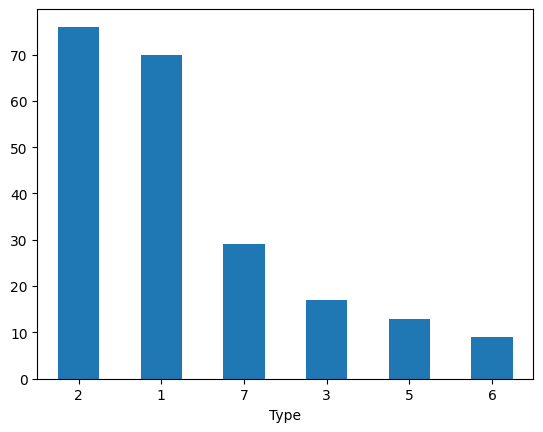

In [ ]:
# Visualizing the distribution of our type column in the data
data.Type.value_counts().plot(kind='bar', rot=0);

<font color = green>We can see that our dataset distribution is highly skewed particularly to the label 1 and label 2 which may be crucial in classifying  later on.

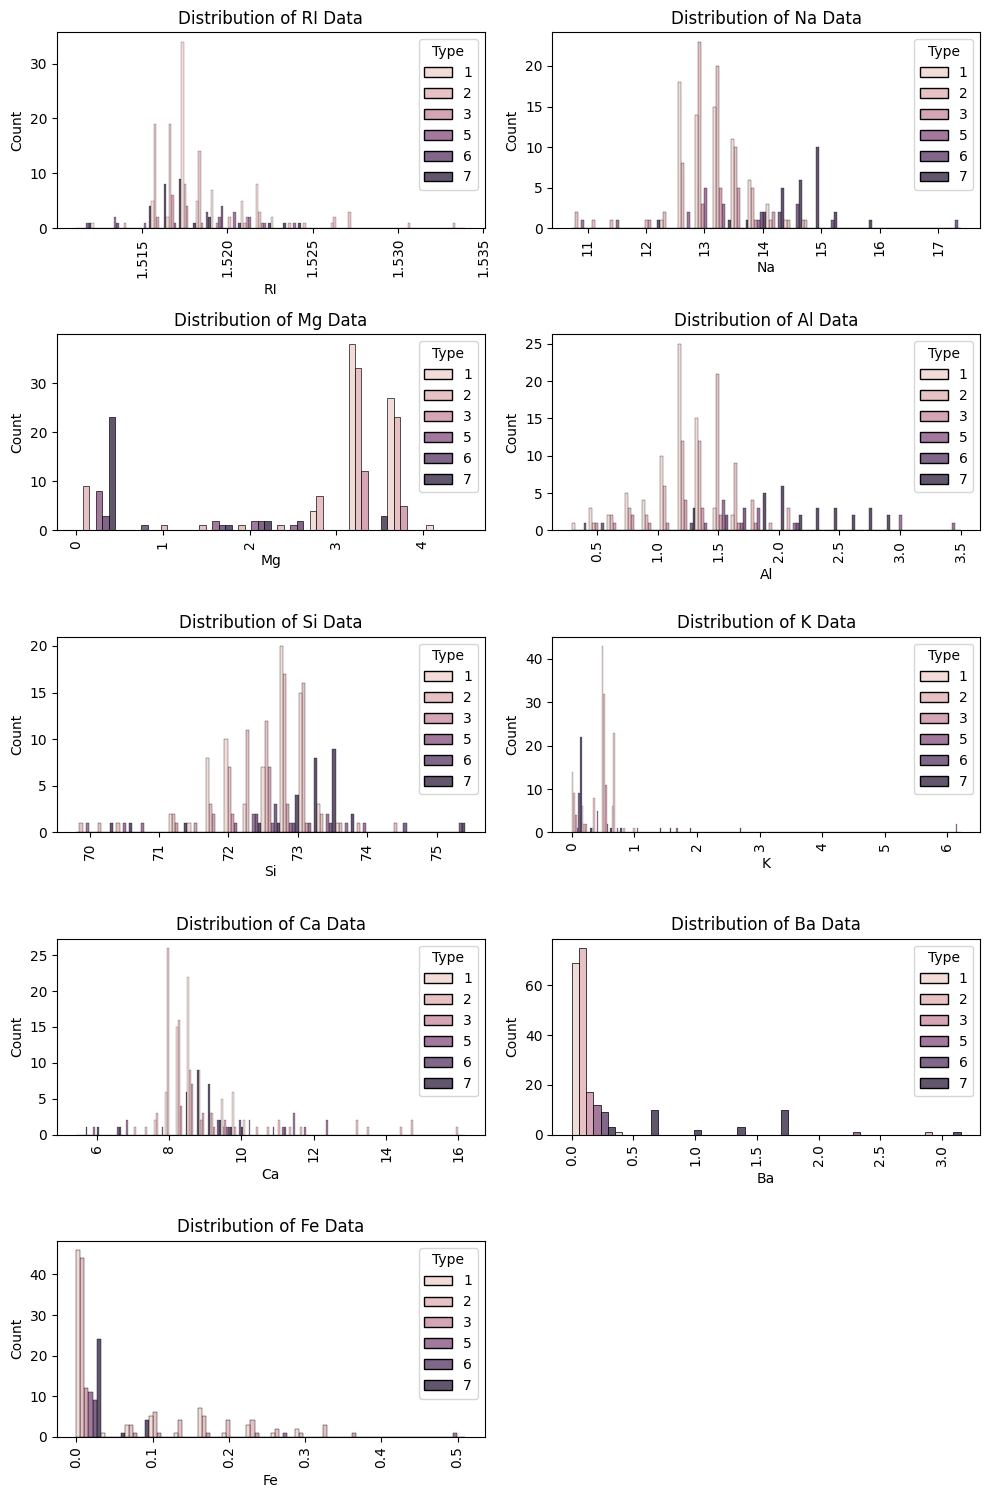

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 15))
for i, col in enumerate(data.columns[:-1], 1):
    plt.subplot(5, 2, i)
    sns.histplot(x = data[col], hue = data["Type"], multiple = "dodge")
    plt.title(f"Distribution of {col} Data")
    plt.tight_layout()
    plt.xticks(rotation = 90)
    plt.plot()

<font color = "green"> **Here is the summary of analysis we got upon exploring the dataset.**
* In RI index, type for building & vehicle windows are most distirbuted in 1.515 ~ 1.520.
* Building & Vehicle window's Na index is in range of 12 ~ 14 and others are in 14 ~ 15.
* Building & Vehicle window's Mg index 2.5 ~ 4 and other windows are below 2.5. Especially, most of others are near in index zero.
* Building & Vehicle window's AI index are below 1.5, but other index are over 1.5.
* Building & Vehicle window's SI index is in 71 ~ 73, but other index are usually in 72 ~ 74.
* Most window types("K") are below 1.
* Building & Vehicle window's Ca index is below 10 and other types are over 8.¶
* Building & Vehicle window's Ba index is near zero and others are over them.
* Building & Vehicle window's Fe index are distributed 0 ~ 0.3, but most are nearly zero. And Other type are most done in 0 ~ 1
</font>

In [ ]:
#Correlation of each columns
df_corr = data.corr()
df_corr["Type"].sort_values(ascending = False)

,Type
Type,1.000000
Al,0.598829
Ba,0.575161
Na,0.502898
Si,0.151565
Ca,0.000952
K,-0.010054
RI,-0.164237
Fe,-0.188278
Mg,-0.744993


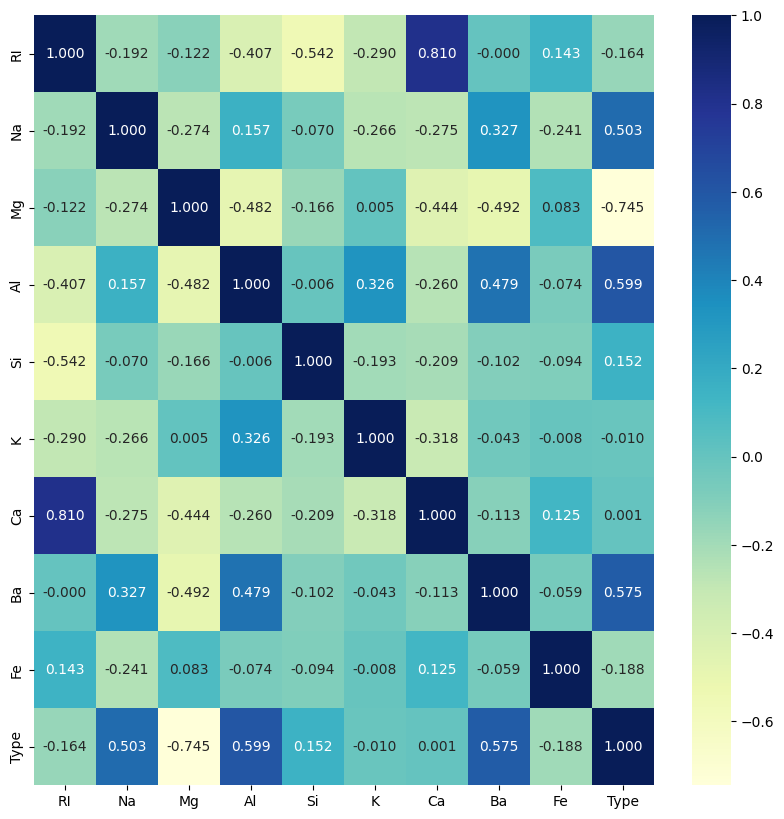

In [ ]:
plt.figure(figsize = (10, 10))
sns.heatmap(df_corr, fmt = ".3f", annot = True, cmap = "YlGnBu")
plt.show()

<font color = green > As we can see in the graph, three features(Al/Ba/Na) are most correlated with type with strong positive correlation while Mg has stron negative correlation with type. Rl & Ca are most correlated in this feature

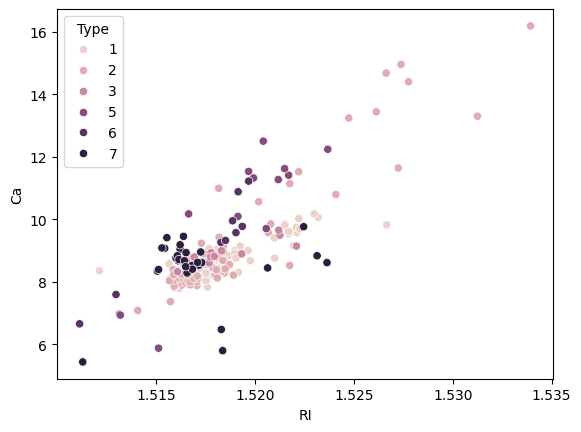

In [ ]:
sns.scatterplot(x = data["RI"], y = data["Ca"], hue = data["Type"])
plt.show()

<font color =green> Building & vehicle windows had a range over 1.515  &  8 in Rl and Ca respectively. Other type Rl & Ca index are each below 1.525 & 12.

In [ ]:
data.Type.value_counts(normalize=True)

,proportion
Type,
2,0.355140
1,0.327103
7,0.135514
3,0.079439
5,0.060748
6,0.042056


Given the skew in the predictor variable, let's split the data with the *churned* values being stratified.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit


feature_cols = [x for x in data.columns if x != 'Type']


# Split the data into two parts with 1500 points in the test data
# This creates a generator
strat_shuff_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the index values from the generator
train_idx, test_idx = next(strat_shuff_split.split(data[feature_cols], data['Type']))

# Create the data sets
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Type']

X_test = data.loc[test_idx, feature_cols]
y_test = data.loc[test_idx, 'Type']

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Type,
2,0.356725
1,0.327485
7,0.134503
3,0.081871
5,0.058480
6,0.040936


In [ ]:
y_test.value_counts(normalize=True)

,proportion
Type,
2,0.348837
1,0.325581
7,0.139535
5,0.069767
3,0.069767
6,0.046512


## Model Training and Evaluation
* Fit random forest models with a range of tree numbers and evaluate the out-of-bag error for each of these models.
* Plot the resulting oob errors as a function of the number of trees.

*Hint:* since the only thing changing is the number of trees, the `warm_start` flag can be used so that the model just adds more trees to the existing model each time. Use the `set_params` method to update the number of trees.

In [ ]:
# Suppress warnings about too few trees from the early models

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the random forest estimator
# Note that the number of trees is not setup here
RF = RandomForestClassifier(oob_score=True,
                            random_state=42,
                            warm_start=True,
                            n_jobs=-1)

oob_list = list()

# Iterate through all of the possibilities for
# number of trees
for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400,600,800]:

    # Use this to set the number of trees
    RF.set_params(n_estimators=n_trees)

    # Fit the model
    RF.fit(X_train, y_train)

    # Get the oob error
    oob_error = 1 - RF.oob_score_

    # Store it
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

rf_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

rf_oob_df

,oob
n_trees,
15.0,0.321637
20.0,0.304094
30.0,0.257310
40.0,0.257310
50.0,0.245614
100.0,0.257310
150.0,0.233918
200.0,0.239766
300.0,0.251462


The error looks like it has stabilized around 400-800 trees.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

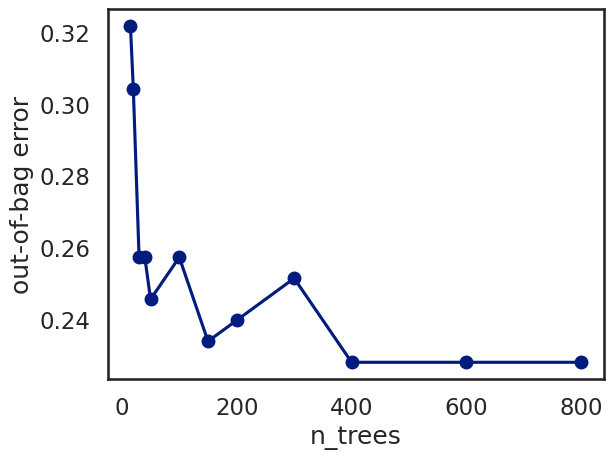

In [ ]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = rf_oob_df.plot(legend=False, marker='o')
ax.set(ylabel='out-of-bag error');

In [ ]:
#import necessary libraries
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Using GridSearch and RandomSearch choose the best parameter for random forest model
rfc = RandomForestClassifier(random_state= 42)

In [ ]:
#Setting up GridSearch parameters for Random Forest
param_grid = {
    'n_estimators': [400, 600,800],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [10,20,30],
    'criterion' :['gini', 'entropy']
}
param_dist = {
    'n_estimators': [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num = 11)],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


In [ ]:
#Perform GridSearchCV for RandomForest
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [400, 600, 800]})

In [ ]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'n_estimators': 400}

In [ ]:
grid_search.best_score_

0.7956302521008404

In [ ]:
random_search = RandomizedSearchCV(estimator=rfc, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [ ]:
random_search.best_params_

{'n_estimators': 1200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 60,
 'bootstrap': True}

In [ ]:
random_search.best_score_

0.7368421052631579

In [ ]:
# Evaluate performance
def evaluate_model(search, X_train, X_test, y_train, y_test, name):
    print(f"Results for {name} Search")
    # Training set performance
    y_train_pred = search.predict(X_train)
    print(f"Training Accuracy: {search.score(X_train, y_train):.4f}")
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))

    # Testing set performance
    y_test_pred = search.predict(X_test)
    print(f"Testing Accuracy: {search.score(X_test, y_test):.4f}")
    print("Testing Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Confusion matrix for test set
    print(f"Confusion Matrix (Test Set) for {name}:")
    print(confusion_matrix(y_test, y_test_pred))

    # AUC-ROC score and curve
    if len(np.unique(y_test)) == 2:
        auc_score = roc_auc_score(y_test, search.predict_proba(X_test)[:, 1])
        print(f"AUC-ROC (Test Set) for {name}: {auc_score:.4f}")

        fpr, tpr, _ = roc_curve(y_test, search.predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f'{name} Search (AUC = {auc_score:.4f})')
    else:
        print(f"{name} AUC-ROC not available for multi-class classification")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve

In [ ]:
evaluate_model(grid_search, X_train, X_test, y_train, y_test, 'Grid')

Results for Grid Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        61
           3       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00        23

    accuracy                           1.00       171
   macro avg       1.00      1.00      1.00       171
weighted avg       1.00      1.00      1.00       171

Testing Accuracy: 0.7907
Testing Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       0.67      0.67      0.67         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80     

In [ ]:
evaluate_model(random_search, X_train, X_test, y_train, y_test, "Random")

Results for Random Search
Training Accuracy: 0.9825
Training Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.98      0.97        56
           2       0.98      1.00      0.99        61
           3       1.00      0.93      0.96        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      0.96      0.98        23

    accuracy                           0.98       171
   macro avg       0.99      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

Testing Accuracy: 0.7674
Testing Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.71      0.67      0.69        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80   

###**Interpretation**

<font color =green>In this activity we evaluate the RandomForest() model performance and find the best parameters using GridSearchCV and RandomizedSearch. As we get to the accuracy of the training and testing, I notice that the GridSearchCV got a 1.0 accuracy on training and  0.7907 on testing. Thus, it suggest that our model is prone to overfit and  misclassify some datapoints. Meanwhile, using  the Randomized Search we got a training accuracy of 0.9825 and a testing accuracy of 0.7674 which is slightly better than the GridSearch result. The overfitting of the model is likely because of the imbalance of our dataset. Overall the AUC-ROC score of our model is not available for multiclass classification and we may conduct a one vs rest as we go through our activity. In this model we may say that Gridsearch is the best hypertuned parameter for randomforest classifier.

## ExtraTrees Classifier model evaluation
* Repeat question 3 using extra randomized trees (`ExtraTreesClassifier`). Note that the `bootstrap` parameter will have to be set to `True` for this model.
* Compare the out-of-bag errors for the two different types of models.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

# Initialize the random forest estimator
# Note that the number of trees is not setup here
EF = ExtraTreesClassifier(oob_score=True,
                          random_state=42,
                          warm_start=True,
                          bootstrap=True,
                          n_jobs=-1)

oob_list = list()

# Iterate through all of the possibilities for
# number of trees
for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400]:

    # Use this to set the number of trees
    EF.set_params(n_estimators=n_trees)
    EF.fit(X_train, y_train)

    # oob error
    oob_error = 1 - EF.oob_score_
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

et_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

et_oob_df

,oob
n_trees,
15.0,0.286550
20.0,0.286550
30.0,0.274854
40.0,0.257310
50.0,0.251462
100.0,0.269006
150.0,0.263158
200.0,0.263158
300.0,0.263158


Combine the two dataframes into a single one for easier plotting.

In [ ]:
oob_df = pd.concat([rf_oob_df.rename(columns={'oob':'RandomForest'}),
                    et_oob_df.rename(columns={'oob':'ExtraTrees'})], axis=1)

oob_df

,RandomForest,ExtraTrees
n_trees,,
15.0,0.321637,0.286550
20.0,0.304094,0.286550
30.0,0.257310,0.274854
40.0,0.257310,0.257310
50.0,0.245614,0.251462
100.0,0.257310,0.269006
150.0,0.233918,0.263158
200.0,0.239766,0.263158
300.0,0.251462,0.263158


The random forest model performs consistently better than the extra randomized trees.

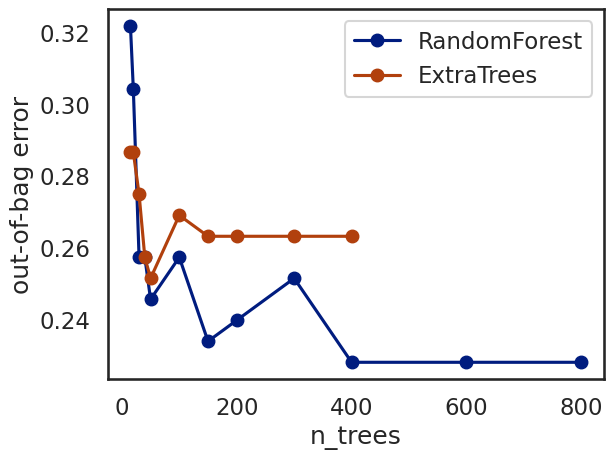

In [ ]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = oob_df.plot(marker='o')
ax.set(ylabel='out-of-bag error');

In [ ]:
#Perform evaluation model in Extra Trees
etc = ExtraTreesClassifier(random_state= 42)


In [ ]:
#Perform Gridsearch
grid_search_etc = GridSearchCV(estimator=etc, param_grid=param_grid, cv= 5)
grid_search_etc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ExtraTreesClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [400, 600, 800]})

In [ ]:
grid_search_etc.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'n_estimators': 600}

In [ ]:
grid_search_etc.best_score_

0.7722689075630252

In [ ]:
#Perform RandomizedSearch
random_search_etc = RandomizedSearchCV(estimator=etc, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)
random_search_etc.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=ExtraTreesClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [ ]:
random_search_etc.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 110,
 'bootstrap': False}

In [ ]:
random_search_etc.best_score_

0.7192982456140351

In [ ]:
#Evaluate the GridSearch CV model
evaluate_model(grid_search_etc, X_train, X_test, y_train, y_test, 'Grid')


Results for Grid Search
Training Accuracy: 0.9825
Training Classification Report:
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        56
           2       1.00      0.98      0.99        61
           3       1.00      0.86      0.92        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00        23

    accuracy                           0.98       171
   macro avg       0.99      0.97      0.98       171
weighted avg       0.98      0.98      0.98       171

Testing Accuracy: 0.7907
Testing Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.86      0.75        14
           2       0.85      0.73      0.79        15
           3       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80     

In [ ]:
#Evaluate RandomizedSearch model
evaluate_model(random_search_etc, X_train, X_test, y_train, y_test, "Random")

Results for Random Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        61
           3       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00        23

    accuracy                           1.00       171
   macro avg       1.00      1.00      1.00       171
weighted avg       1.00      1.00      1.00       171

Testing Accuracy: 0.8140
Testing Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.79      0.76        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80   

###**Interpretation**
<font color = "green">
In this activity we evaluate the ExtraTrees model performance and find the best parameters using GridSearchCV and RandomizedSearch. As we get to the accuracy of the training and testing, I notice that the GridSearchCV got a 98.25% accuracy on training and  79.07% on testing. Thus, it suggest that our model is prone to overfit and  misclassify some datapoints. Meanwhile, using  the Randomized Search we got a training accuracy of 1 and a testing accuracy of 0.8140 which is slightly better than the GridSearch result and the rest of the model we train. The overfitting of the model is likely because of the imbalance of our dataset. Overall the AUC-ROC score of our model is around 0.84 which suggest that our model performance is slightly good on the hypertuned parameters using Random Seach. We also see that our model in our random search is 200.

## Metrics Evaluation

* Select one of the models that performs well and calculate error metrics and a confusion matrix on the test data set.
* Given the distribution of the predicted class, which metric is most important? Which could be deceiving?

In [ ]:
# Random forest with 100 estimators
model = RF.set_params(n_estimators=200)

y_pred = model.predict(X_test)

Unsurprisingly, recall is rather poor for the customers who churned (True) class since they are quite small. We are doing better than random guessing, though, as the accuracy is 0.932 (vs 0.85 for random guessing).

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

cr = classification_report(y_test, y_pred)
print(cr)

# Get predicted probabilities instead of class labels
y_pred_proba = model.predict_proba(X_test)

score_df = pd.DataFrame({'accuracy': accuracy_score(y_test, y_pred),
                         'precision': precision_score(y_test, y_pred, average='weighted'), # Added average='weighted'
                         'recall': recall_score(y_test, y_pred, average='weighted'), # Added average='weighted'
                         'f1': f1_score(y_test, y_pred, average='weighted'), # Added average='weighted'
                         'auc': roc_auc_score(y_test, y_pred_proba, multi_class='ovr')}, # Added multi_class='ovr' for multiclass AUC
                         index=pd.Index([0]))

print(score_df)

              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43

   accuracy  precision    recall        f1       auc
0  0.837209   0.854221  0.837209  0.835527  0.971606


In [ ]:
model = RF.set_params(n_estimators=400)

In [ ]:

y_pred2 = model.predict(X_train)

In [ ]:
cr = classification_report(y_train, y_pred2)
print(cr)


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        61
           3       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00        23

    accuracy                           1.00       171
   macro avg       1.00      1.00      1.00       171
weighted avg       1.00      1.00      1.00       171



In [ ]:
y_pred_proba2 = model.predict_proba(X_train) # Get probabilities for the training set
score_df = pd.DataFrame({'accuracy': accuracy_score(y_train, y_pred2),
                         'precision': precision_score(y_train, y_pred2,average='weighted'),
                         'recall': recall_score(y_train, y_pred2,average='weighted'),
                         'f1': f1_score(y_train, y_pred2,average='weighted'),
                         'auc': roc_auc_score(y_train, y_pred_proba2,multi_class='ovr')}, # Use y_pred_proba instead of y_pred2
                         index=pd.Index([0]))

print(score_df)


   accuracy  precision  recall   f1  auc
0       1.0        1.0     1.0  1.0  1.0


<font color=green> In testing the activity the important metrics we need to focus are precision and recall, f1-score and ROC-AUC . This metrics is important to measure the accuracy of positive prediction and find all positive instances. F1 score also provide a harmonic mean for the precision and mean  while ROC-AUC  evaluate trade-off  which gives a comprehensive view for model performance  between true positive and false positive rate in different tresholds.

<font color=green> the potential deceiving metrics are the accuracy that lead to misleading some classification and also the confusion matrix which may not be interpreted correctly.

## Question 6

* Print or visualize the confusion matrix.
* Plot the ROC-AUC and precision-recall curves.
* Plot the feature importances.

Text(0.5, 6.8833333333333275, 'Ground Truth')

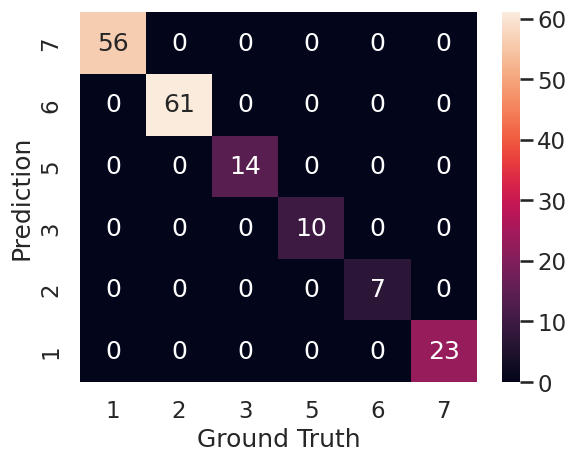

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

sns.set_context('talk')
cm = confusion_matrix(y_train, y_pred2)
ax = sns.heatmap(cm, annot=True, fmt='d')

# Get the unique class labels from y_train
labels = sorted(list(set(y_train)))

# Convert labels to string if needed
labels = [str(label) for label in labels]

ax.set_xticklabels(labels);
ax.set_yticklabels(labels[::-1]);
ax.set_ylabel('Prediction');
ax.set_xlabel('Ground Truth')

The ROC-AUC and precision-recall curves.

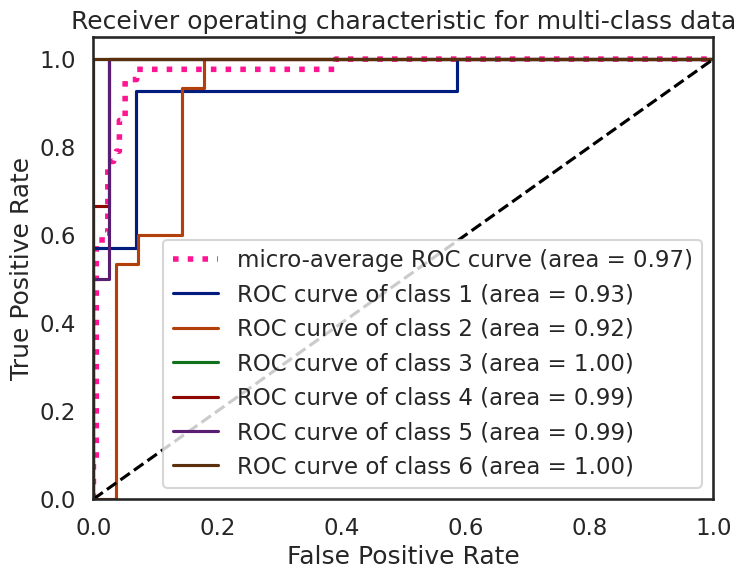

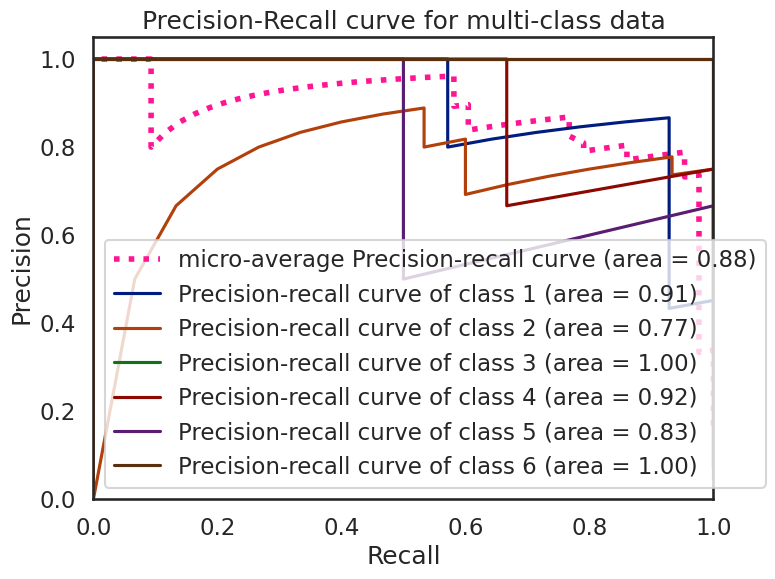

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba_bin = model.predict_proba(X_test)

n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba_bin.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i+1, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for multi-class data')
plt.legend(loc="lower right")
plt.show()


# Compute Precision-Recall curve and area for each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i],
                                                        y_pred_proba_bin[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_proba_bin[:, i])

# Compute micro-average ROC curve and ROC area
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_test_bin.ravel(), y_pred_proba_bin.ravel())
average_precision["micro"] = average_precision_score(y_test_bin, y_pred_proba_bin, average="micro")


# Plot Precision-Recall curve for each class
plt.figure(figsize=(8, 6))
plt.plot(recall["micro"], precision["micro"],
         label='micro-average Precision-recall curve (area = {0:0.2f})'
               ''.format(average_precision["micro"]),
         color='deeppink', linestyle=':', linewidth=4)


for i in range(n_classes):
    plt.plot(recall[i], precision[i], label='Precision-recall curve of class {0} (area = {1:0.2f})'
                                   ''.format(i+1, average_precision[i]))


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall curve for multi-class data')
plt.legend(loc="lower left")
plt.show()

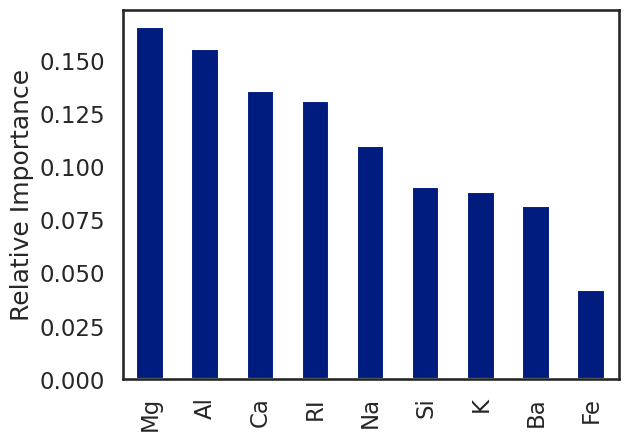

In [ ]:
feature_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance');

The feature importances. Magnesium  is the biggest predictor of glass classification followed by Aluminum. The lowest feature importance is Iron which  is around 0.040. This features are important for our model to compute the weight of each prediction we have.

#Bagging Model

In [ ]:
# prompt: Make a bagging classifier in the glass dataset

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import ExtraTreeClassifier

# Create a Bagging Classifier with a Decision Tree as the base estimator
bagging_model = BaggingClassifier(ExtraTreeClassifier(),
                                 n_estimators=200,  # Number of trees/models in the ensemble
                                 random_state=42)

# Train the Bagging model
bagging_model.fit(X_train, y_train)

# Evaluate the Bagging model
y_pred_bagging = bagging_model.predict(X_test)
print("Bagging Classifier Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Bagging Classifier Classification Report:")
print(classification_report(y_test, y_pred_bagging))



Bagging Classifier Accuracy: 0.8372093023255814
Bagging Classifier Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.86      0.80      0.83        15
           3       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.82        43
weighted avg       0.85      0.84      0.83        43



In [ ]:
#Wecan also perform hyperparameter tuning for the BaggingClassifier using GridSearchCV or RandomizedSearchCV
# similar to what was done for RandomForest and ExtraTrees.


param_grid_bagging = {
     'n_estimators': [50, 100, 200],
     'max_samples': [0.5, 0.7, 1.0],
     'max_features': [0.5, 0.7, 1.0]
}
grid_search_bagging = GridSearchCV(estimator=bagging_model, param_grid=param_grid_bagging, cv=5)
grid_search_bagging.fit(X_train, y_train)
print("Best Bagging Parameters:", grid_search_bagging.best_params_)

Best Bagging Parameters: {'max_features': 0.7, 'max_samples': 0.7, 'n_estimators': 100}


In [ ]:
#evaluate the model
evaluate_model(grid_search_bagging, X_train, X_test, y_train, y_test, 'Bagging')

Results for Bagging Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        61
           3       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00        23

    accuracy                           1.00       171
   macro avg       1.00      1.00      1.00       171
weighted avg       1.00      1.00      1.00       171

Testing Accuracy: 0.7674
Testing Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.75      0.80      0.77        15
           3       0.00      0.00      0.00         3
           5       1.00      0.67      0.80         3
           6       0.50      0.50      0.50  

## Conclusion:
In this activity, I learned how  random forest and extra trees work on the data. We also got to evaluate the model performance and compare each accuracy based on the given parameters using GridSearchCV and Randomized Search. We also plot the importances features that can affect to the prediction of our model. In performing the Bagging classifier, we saw that  a hypertuned model isnt always have the best parameter as we can see that our model performance in gridsearch has a low accuracy with 0.7674 while our standard bagging which has extratrees classifier as our base estimator had a 0.83 which is better compare to the hypertuned parameters.
